# **MACHINE LEARNING**
## **K-Means + Clasificación Supervisada — California Housing**

# **PASO 1: Carga del conjunto de datos**

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [43]:
# Carga del dataset California Housing
url = "https://breathecode.herokuapp.com/asset/internal-link?id=809&path=housing.csv"
df_full = pd.read_csv(url)

print("Shape completo del dataset:", df_full.shape)
print("Columnas disponibles:", list(df_full.columns))
df_full.head(10)

Shape completo del dataset: (20640, 9)
Columnas disponibles: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


El dataset contiene datos del censo de California de 1990 y tiene una fila por grupo de bloques censales. Tiene **20.640 filas** y **9 columnas** que recogen características demográficas y económicas.

# **PASO 2: Análisis Exploratorio de Datos (EDA)**

In [44]:
# Vista general del dataset completo
print("TIPOS DE DATOS")
df_full.info()

print("\n ESTADÍSTICAS DESCRIPTIVAS")
df_full.describe().round(3)

TIPOS DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB

 ESTADÍSTICAS DESCRIPTIVAS


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000



Todas las columnas son numéricas, lo que simplifica el preprocesamiento. En las estadísticas descriptivas podemos destacar:
- **Escalas muy dispares**: `Population` puede superar 35.000, mientras que `AveBedrms` ronda 1–2. Con estos desbalances es necesario el escalado para K-Means.
- **`MedInc`** va de ~0.5 a ~15 (en decenas de miles de dólares), con media alrededor de 3.9.
- **`Latitude`** entre ~32 y ~42, y **`Longitude`** entre ~-124 y ~-114, cubriendo el estado completo, de este a oeste y de norte a sur.
- **`AveRooms`** y **`AveOccup`** tienen outliers extremos: algunos bloques registran cientos de habitaciones de media, lo quepuede ser un posible error de censo.

In [45]:
# Valores nulos
nulos = df_full.isnull().sum()
pct   = (nulos / len(df_full) * 100).round(2)

resumen_nulos = pd.DataFrame({'Nulos': nulos, '% del total': pct})
print("Valores nulos por columna:")
print(resumen_nulos[resumen_nulos['Nulos'] > 0] if nulos.any() else "Sin valores nulos en ninguna columna ")

Valores nulos por columna:
Sin valores nulos en ninguna columna 


El dataset no tiene valores nulos en ninguna columna, esto simplifica mucho el pipeline. No necesitamos estrategias de imputación y podemos pasar al análisis de distribuciones.

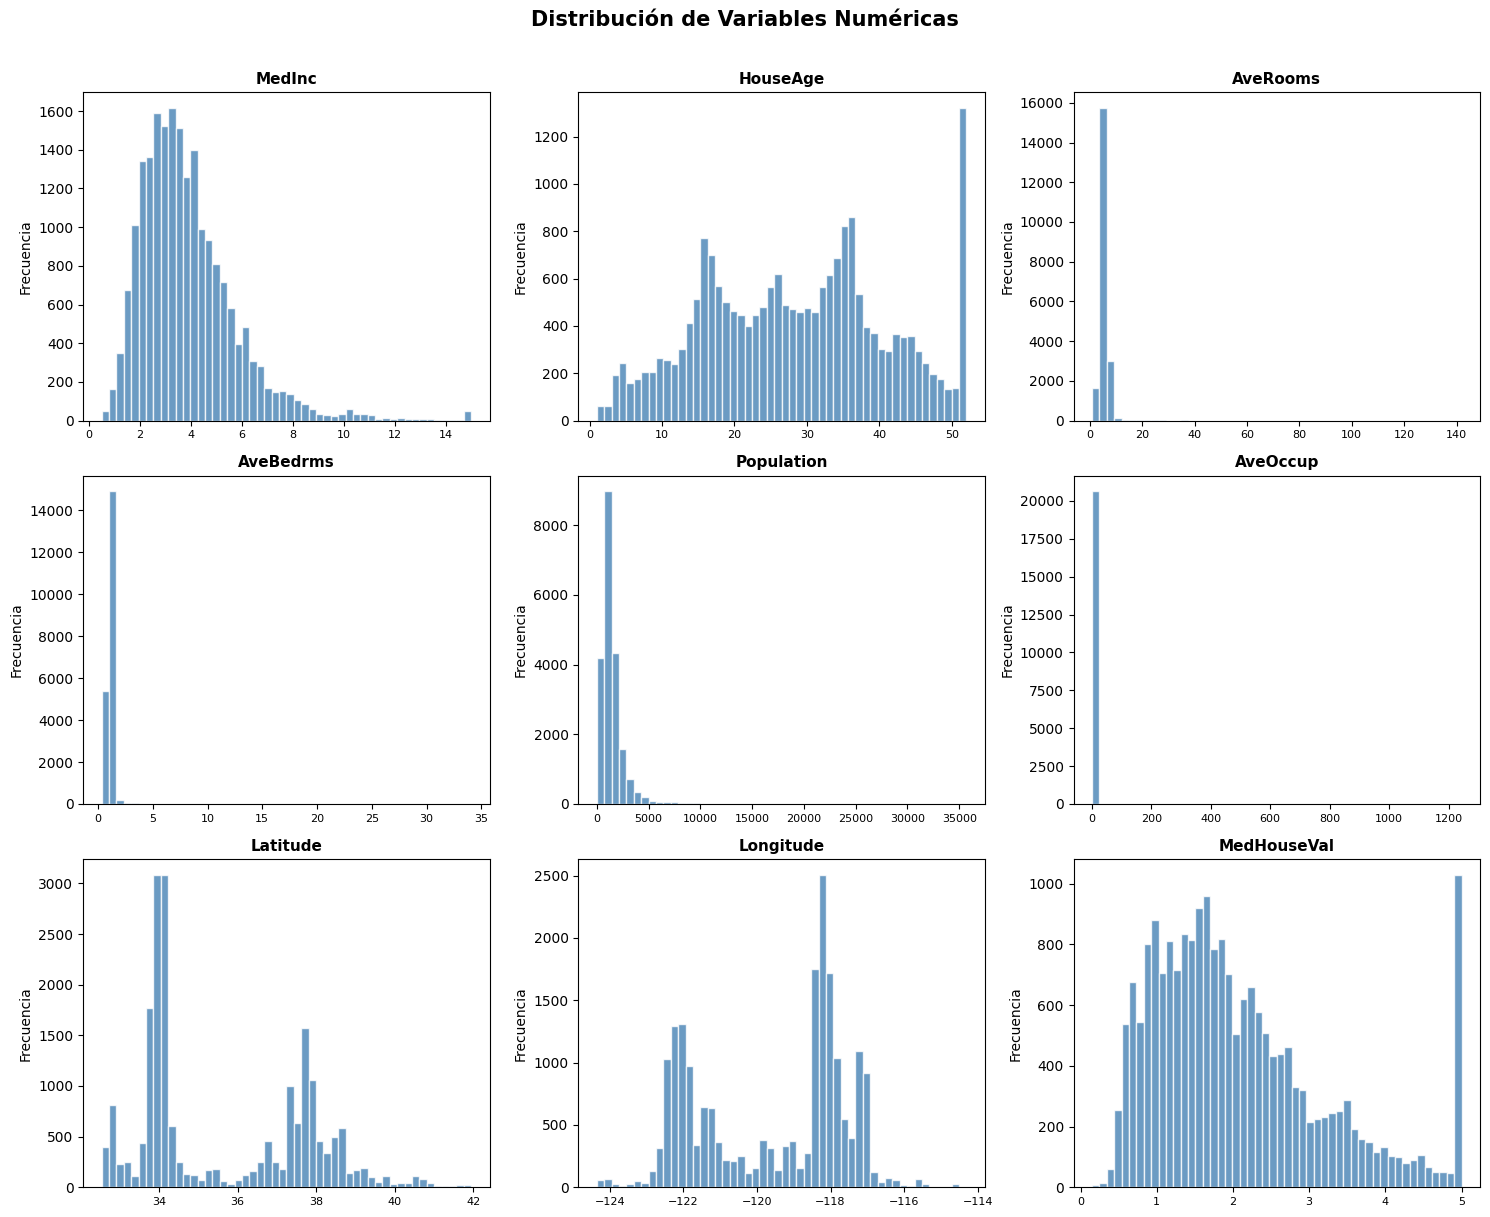

In [46]:
# Histogramas de todas las variables
num_cols = df_full.columns.tolist()

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df_full[col],
                 bins=50,
                 color='steelblue',
                 edgecolor='white',
                 alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Frecuencia')
    axes[i].tick_params(axis='x', labelsize=8)

plt.suptitle('Distribución de Variables Numéricas', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Los histogramas revelan varias observaciones importantes:
- `MedInc`: distribución log-normal con cola a la derecha. La mayoría de bloques tienen ingresos entre 2 y 5 equivalente a 20.000 a 50.000 dollares al año.
- `HouseAge`: acumulación pronunciada en 52 años, esto se puede deber a que el censo esta hecho en 1990.
- `AveRooms` y `AveBedrms`: muy sesgados, con outliers extremos puede ser por grandes edificios o errores de registro.
- `Population` y `AveOccup`: fuerte sesgo a la derecha, con algunos bloques con picos de ocupación muy altos.
- `Latitude` y `Longitude`: distribuciones **bimodales**, reflejan la concentración de población en dos áreas, Los Ángeles y San Francisco.
- `MedHouseVal`: acumulación en 500.001 $, otro posible techo artificial del censo.

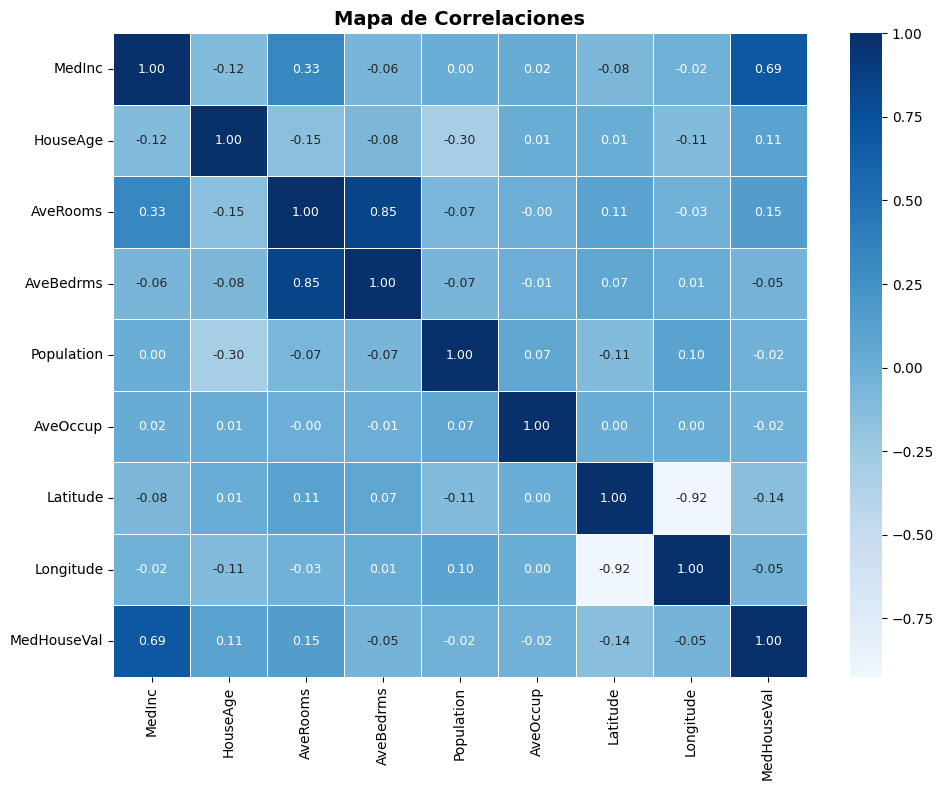

In [47]:
# Mapa de correlaciones
corr = df_full.corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    center=0,
    linewidths=0.5,
    linecolor='white',
    annot_kws={'size': 9}
)
plt.title('Mapa de Correlaciones', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



El heatmap nos muestra relaciones clave entre las variables:
- **`MedInc` & `MedHouseVal`**: correlación positiva más alta del dataset (~0.69). Es la relación que más información nos proporciona para predecir el precio de la vivienda.
- **`Latitude` & `Longitude`**: correlación negativa fuerte (~-0.92), tiene sentido y es esperada ya que la forma del estado de California es diagonal.
- **`AveRooms` & `MedInc`**: correlación positiva moderada; las zonas con mayor ingreso tienen viviendas con más habitaciones, totalmente lógico.
- **`Latitude` & `MedHouseVal`**: correlación negativa (~-0.14), las zonas del sur (Los Ángeles) tienden a ser más caras que el norte o el interior.
- **`AveOccup`** tiene correlaciones muy bajas con todo.

Distribución por franja de ingreso:
income_zone
Medio (2-4)      10096
Alto (4-6)        5725
Bajo (<2)         2457
Muy alto (>6)     2362
Name: count, dtype: int64


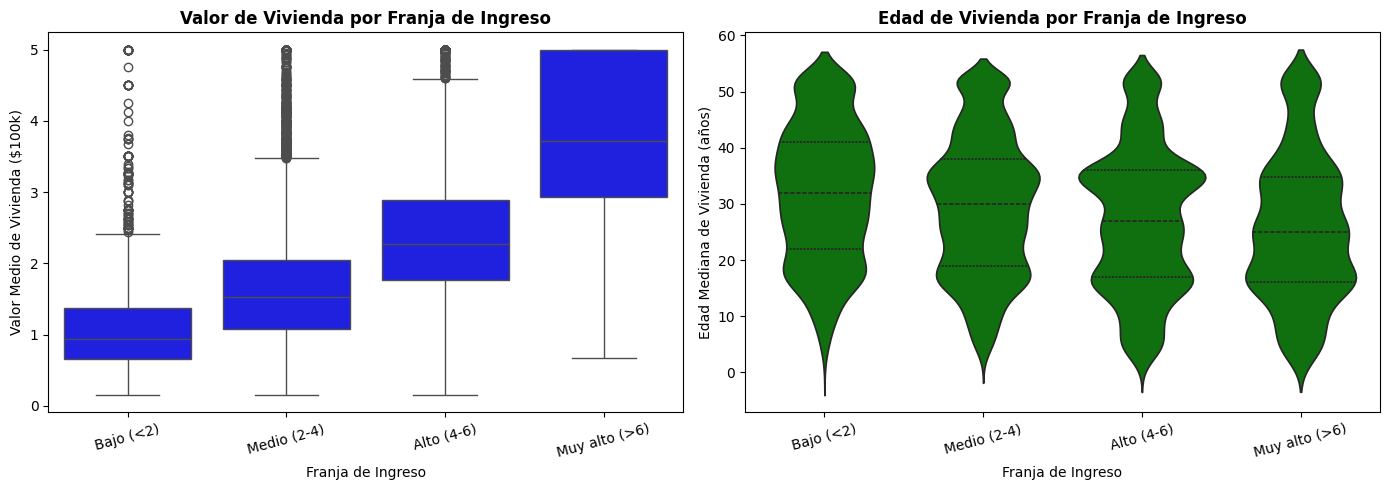

In [48]:
# Creamos franjas de ingreso para comparar zonas económicas
df_full['income_zone'] = pd.cut(
    df_full['MedInc'],
    bins=[0, 2, 4, 6, 20],
    labels=['Bajo (<2)', 'Medio (2-4)', 'Alto (4-6)', 'Muy alto (>6)']
)

# Distribución de las franjas
print("Distribución por franja de ingreso:")
print(df_full['income_zone'].value_counts())

# Boxplot de valor de vivienda por franja de ingreso
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orden = ['Bajo (<2)', 'Medio (2-4)', 'Alto (4-6)', 'Muy alto (>6)']
sns.boxplot(data=df_full,
            x='income_zone',
            y='MedHouseVal',
            order=orden,
            color='Blue',
            ax=axes[0])
axes[0].set_title('Valor de Vivienda por Franja de Ingreso', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Franja de Ingreso')
axes[0].set_ylabel('Valor Medio de Vivienda ($100k)')
axes[0].tick_params(axis='x', rotation=15)

sns.violinplot(data=df_full,
               x='income_zone',
               y='HouseAge',
               order=orden,
               color='green',
               ax=axes[1],
               inner='quartile')
axes[1].set_title('Edad de Vivienda por Franja de Ingreso', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Franja de Ingreso')
axes[1].set_ylabel('Edad Mediana de Vivienda (años)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Creamos franjas de ingreso para comparar el comportamiento de otras variables entre los diferentes grupos económicos.
- El boxplot nos confirma que el valor de vivienda crece con el ingreso, aunque tiene mucha variabilidad dentro de cada franja.
- El violin plot de edad revela algo interesante: las zonas de **ingreso muy alto** tienen viviendas más antiguas, mientras que las zonas de ingreso medio-bajo tienen viviendas más nuevas, puede parecer contradictorio pero tiene mucho sentido.


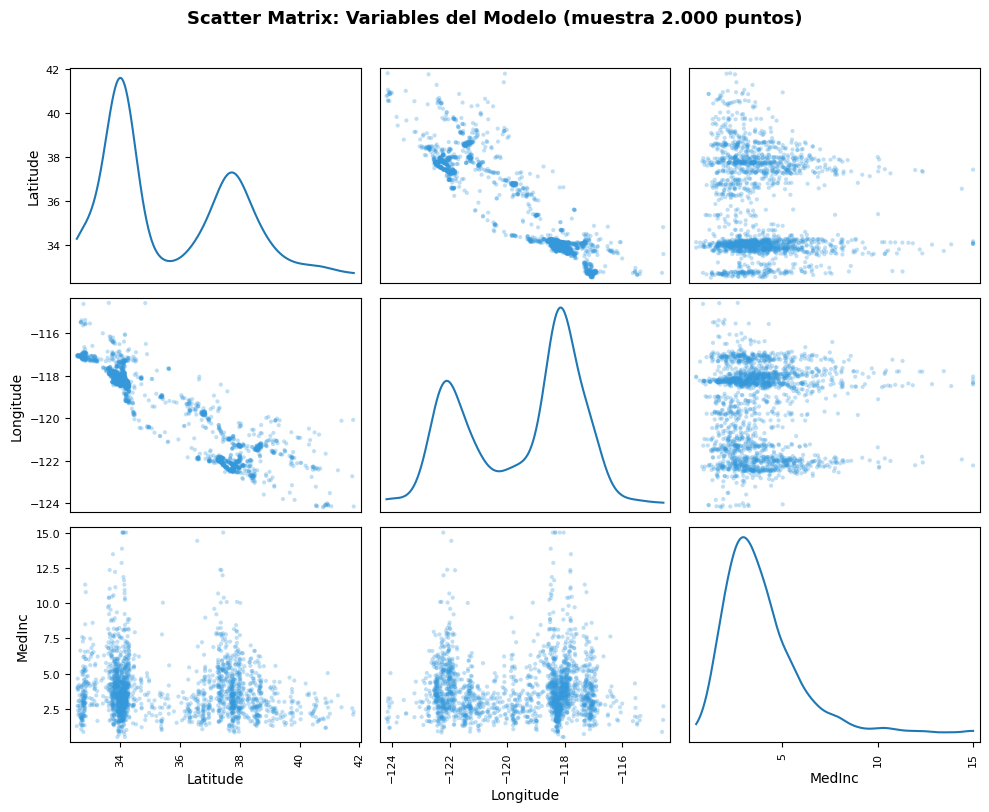

In [49]:
# Scatter matrix de las 3 variables del modelo (muestra 2.000 puntos)
df_modelo = df_full[['Latitude', 'Longitude', 'MedInc']].sample(2000, random_state=42)

axes_matrix = pd.plotting.scatter_matrix(
    df_modelo, figsize=(10, 8),
    diagonal='kde', alpha=0.3,
    color='#3498db',
    hist_kwds={'color': '#2ecc71', 'bins': 30}
)

plt.suptitle('Scatter Matrix: Variables del Modelo (muestra 2.000 puntos)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

La scatter matrix de las tres variables del modelo muestra:
- **Latitude vs Longitude**: el patrón en forma de L invertida que dibuja la costa de California. Fuerte correlación negativa.
- **Lat/Long vs MedInc**: alta dispersión sin tendencia lineal clara, lo que indica que el ingreso aporta información adicional aparte de la posición geográfica. Esto enriquece el clustering.
- Las KDEs diagonales confirman la bimodalidad en coordenadas y la asimetría en ingreso.

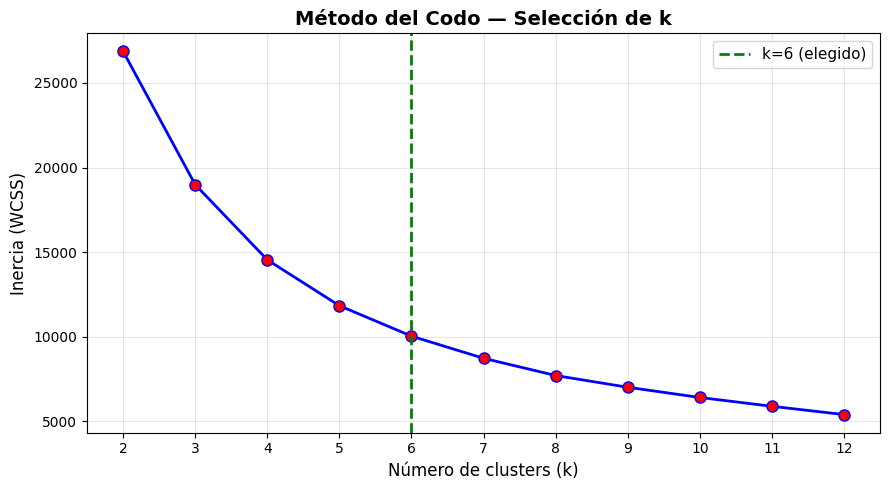

In [50]:
# Método del codo
df_modelo_completo = df_full[['Latitude', 'Longitude', 'MedInc']].copy()
df_modelo_scaled   = StandardScaler().fit_transform(df_modelo_completo)

inercias = []
k_range  = range(2, 13)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(df_modelo_scaled)
    inercias.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range,
         inercias,
         marker='o',
         linewidth=2,
         color='blue',
         markerfacecolor='red',
         markersize=8)
plt.axvline(6, color='green', linestyle='--', linewidth=2, label='k=6 (elegido)')
plt.title('Método del Codo — Selección de k', fontsize=14, fontweight='bold')
plt.xlabel('Número de clusters (k)', fontsize=12)
plt.ylabel('Inercia (WCSS)', fontsize=12)
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

El método del codo grafica la inercia respecto al número de clusters. La reducción de inercia se ralentiza alrededor de k=4–6. **k=6 está bien justificado**: capta las principales zonas de California sin fragmentar demasiado y manteniendo el modelo legible.

# **PASO 3: Preparación del dataset de modelado**

In [51]:
# Seleccionamos las 3 columnas del modelo y dividimos train/test
df = df_full[['Latitude', 'Longitude', 'MedInc']].copy()

X = df.copy()
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print(f"Tamaño entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño prueba:        {X_test.shape[0]} muestras")

Tamaño entrenamiento: 16512 muestras
Tamaño prueba:        4128 muestras


Selecciono las tres columnas más útiles del dataset y se hace el split 80/20 **antes** de entrenar K-Means, evitando así la fuga de información (data lekeage).

# **PASO 4: K-Means — 6 Clusters**

In [52]:
# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# K-Means con 6 clusters
N_CLUSTERS = 6
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

X_train = X_train.copy()
X_train['cluster'] = kmeans.labels_.astype(str)

print("Distribución de muestras por cluster (train):")
print(X_train['cluster'].value_counts().sort_index())

Distribución de muestras por cluster (train):
cluster
0    1321
1    3380
2     453
3    3931
4    2239
5    5188
Name: count, dtype: int64


Escalamos con `StandardScaler` muy importante este paso debido a la diferencia de escalas que tenemos en el dataset y entrenamos con **k=6**, valor obtenido por el método del codo. La columna `cluster` se mantiene como string categórico. La distribución de clusters refleja la desigualdad de la poblacion en California: los clusters de LA y SF son más densos que los clusters del interior.

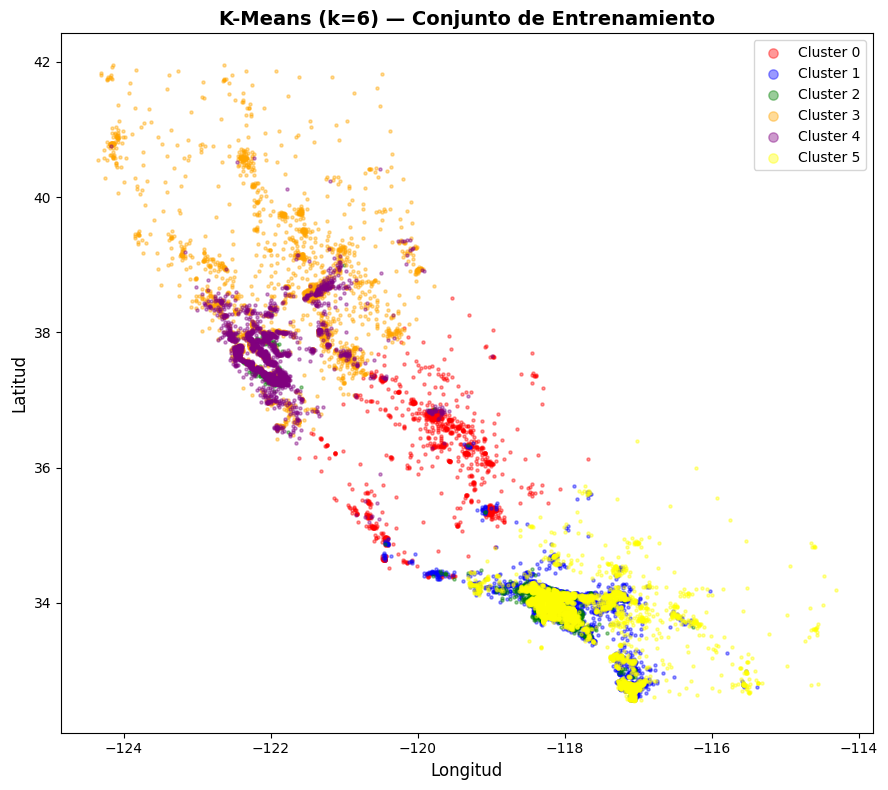

In [55]:
colores = ['red', 'blue', 'green', 'orange', 'purple', 'yellow']
palette = {str(i): colores[i] for i in range(N_CLUSTERS)}

plt.figure(figsize=(9, 8))
for cluster_id, grupo in X_train.groupby('cluster'):
    plt.scatter(
        grupo['Longitude'],
        grupo['Latitude'],
        c=palette[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.4,
        s=5
    )
plt.title('K-Means (k=6) — Conjunto de Entrenamiento', fontsize=14, fontweight='bold')
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.legend(markerscale=3, fontsize=10)
plt.tight_layout()
plt.show()

Los 6 clusters se distribuyen geográficamente de manera coherente con la geografía real del estado. Al haber combinado posición e ingreso, dos zonas contiguas con ingresos distintos pueden pertenecer a clusters diferentes, esto enriquece el agrupamiento más allá de una mera división geográfica.

# **PASO 5: Predicción sobre el conjunto de test**


Distribución de muestras por cluster (test):
cluster
0     337
1     829
2     112
3     962
4     514
5    1374
Name: count, dtype: int64


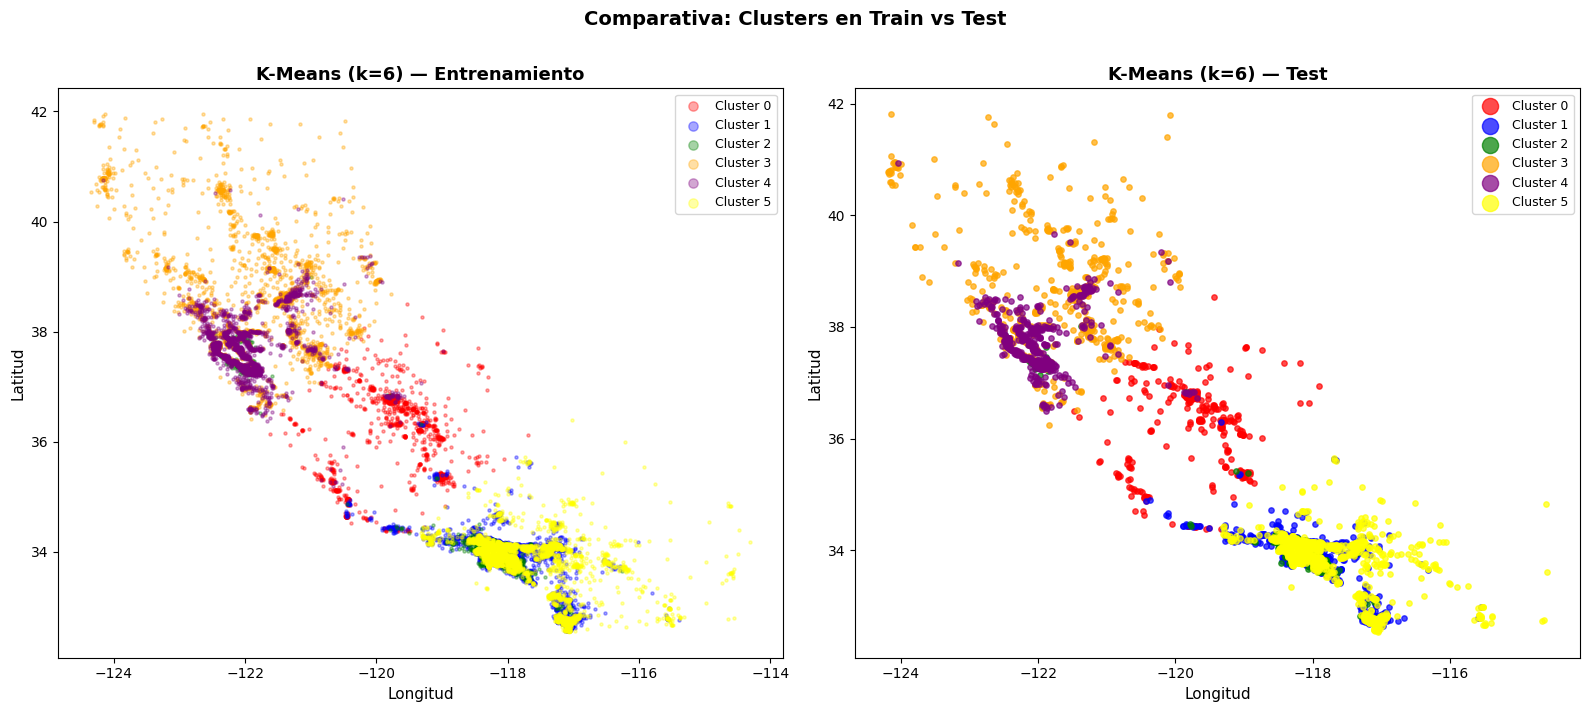

In [57]:
# Predicción de clusters para el conjunto de test
# Lo hago en misma celda para que la columna 'cluster' esté disponible
# en el gráfico, me estuvo dando mucha guerra
X_test = X_test.copy()
X_test['cluster'] = kmeans.predict(X_test_scaled).astype(str)

print("Distribución de muestras por cluster (test):")
print(X_test['cluster'].value_counts().sort_index())

# Gráfica comparativa train vs test
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (data, titulo, size, alpha) in zip(axes, [
    (X_train, 'Entrenamiento', 5,  0.35),
    (X_test,  'Test',         15, 0.7)
]):
    for cluster_id, grupo in data.groupby('cluster'):
        ax.scatter(
            grupo['Longitude'], grupo['Latitude'],
            c=palette[cluster_id], label=f'Cluster {cluster_id}',
            alpha=alpha, s=size
        )
    ax.set_title(f'K-Means (k=6) — {titulo}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longitud', fontsize=11)
    ax.set_ylabel('Latitud', fontsize=11)
    ax.legend(markerscale=3, fontsize=9)

plt.suptitle('Comparativa: Clusters en Train vs Test', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


`kmeans.predict()` asigna cada punto del test al centroide más cercano del modelo ya entrenado. Si la distribución de clusters coincide con la del train, confirma que el split es correcto. Los puntos del test caen en las mismas regiones que el train y reciben el mismo color de cluster, las fronteras son coherentes entre ambos conjuntos.

# **PASO 6: Modelo de clasificación supervisada**

In [59]:
X_sup_train = X_train[['Latitude', 'Longitude', 'MedInc']]
y_sup_train = X_train['cluster'].astype(int)
X_sup_test  = X_test[['Latitude', 'Longitude', 'MedInc']]
y_sup_test  = X_test['cluster'].astype(int)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_sup_train, y_sup_train)

y_pred = rf.predict(X_sup_test)
acc = accuracy_score(y_sup_test, y_pred)
print(f"Accuracy del clasificador supervisado: {acc:.4f}")

Accuracy del clasificador supervisado: 0.9952


Elegí **Random Forest**: es fuerte ante al sobreajuste, no necesita escalado, va a manejar bien las 6 clases y ofrece importancia de variables. Aprende directamente de lat/long/ingreso a predecir el cluster y no necesita K-Means en producción.

In [60]:
print("  CLASSIFICATION REPORT — Random Forest")
print(classification_report(
    y_sup_test, y_pred,
    target_names=[f'Cluster {i}' for i in range(N_CLUSTERS)]
))

  CLASSIFICATION REPORT — Random Forest
              precision    recall  f1-score   support

   Cluster 0       0.99      0.99      0.99       337
   Cluster 1       1.00      1.00      1.00       829
   Cluster 2       1.00      0.98      0.99       112
   Cluster 3       0.99      0.99      0.99       962
   Cluster 4       0.99      1.00      0.99       514
   Cluster 5       1.00      1.00      1.00      1374

    accuracy                           1.00      4128
   macro avg       0.99      0.99      0.99      4128
weighted avg       1.00      1.00      1.00      4128



Precision, recall y F1 por cluster. Los errores, he conseguido disminuirlos al máximo aún así, los que hay, se encuentran en zonas de frontera entre clusters cercanos donde el ingreso puede ser similar.

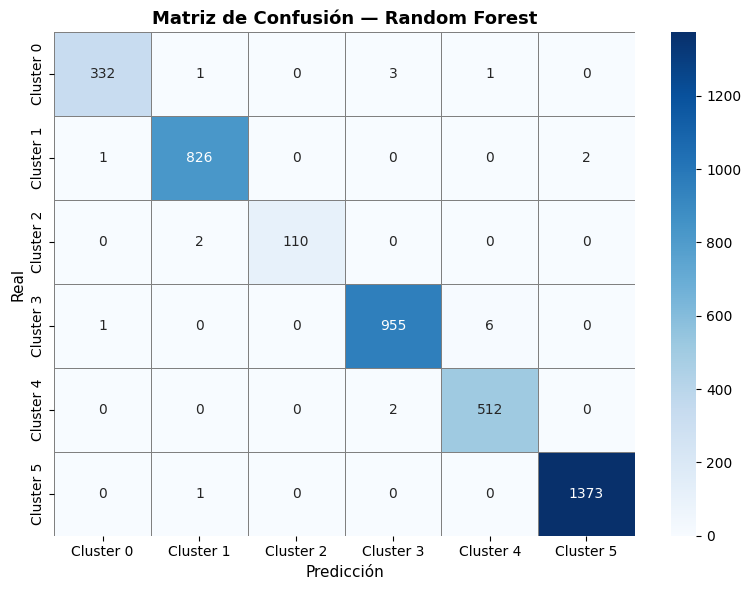

In [61]:
cm = confusion_matrix(y_sup_test, y_pred)
labels = [f'Cluster {i}' for i in range(N_CLUSTERS)]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=labels,
            yticklabels=labels,
            linewidths=0.5,
            linecolor='gray')
plt.title('Matriz de Confusión — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Predicción', fontsize=11)
plt.ylabel('Real', fontsize=11)
plt.tight_layout()
plt.show()

La diagonal marcada  nos confirma que Random Forest reproduce las fronteras de K-Means. Los errores fuera de la diagonal corresponden a puntos en zonas de transición entre clusters cercanos como ya explique.

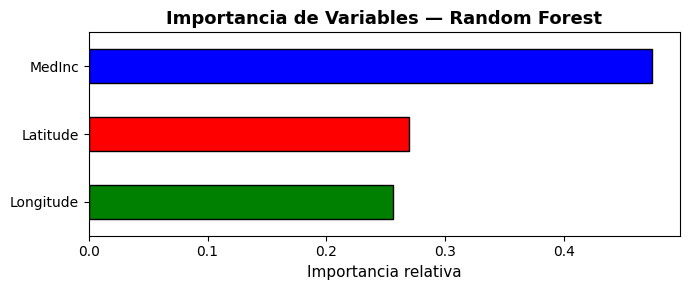

MedInc       0.474329
Latitude     0.269684
Longitude    0.255988
dtype: float64


In [63]:
importancias = pd.Series(
    rf.feature_importances_,
    index=['Latitude', 'Longitude', 'MedInc']
).sort_values(ascending=True)

plt.figure(figsize=(7, 3))
importancias.plot(kind='barh',
                  color=['green', 'red', 'blue'],
                  edgecolor='black')
plt.title('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importancia relativa', fontsize=11)
plt.tight_layout()
plt.show()
print(importancias.sort_values(ascending=False))

La importancia de variables muestra qué dimensión domina la definición de los clusters. Entendí que para poder utilizar correctamente los cluster `Latitude` y `Longitude` iban a ser dos variables clave. `MedInc` es la otra variable clave, ya que indirectamente nos indica que tipo de casa tiene cada propietario en base a sus ingresos.

# **PASO 7: Guardado de los modelos**

In [65]:
os.makedirs('models', exist_ok=True)

joblib.dump(kmeans, 'models/kmeans_california.pkl')
joblib.dump(scaler, 'models/scaler_california.pkl')
joblib.dump(rf,     'models/random_forest_california.pkl')

print("Modelos guardados:")
print("   - models/kmeans_california.pkl")
print("   - models/scaler_california.pkl")
print("   - models/random_forest_california.pkl")

Modelos guardados:
   - models/kmeans_california.pkl
   - models/scaler_california.pkl
   - models/random_forest_california.pkl


Guardado de los tres artefactos:
- Scaler: para preprocesar nuevos datos antes de K-Means
- K-Means: clustering
- Random Forest: clasificador rápido para producción

Con estos tres ficheros puedo reproducir el pipeline completo en cualquier entorno/proyecto.

## Conclusiones finales

- El **EDA** ha facilitado la infomación de distribuciones sesgadas, techos artificiales del censo, alta correlación entre ingreso y valor de vivienda y por último patrones económicos diferenciados por zona.
- El **método del codo** validó k=6 como elección justificada, capturando las regiones de California más destacadas.
- **K-Means** segmentó las casas en 6 regiones coherentes geográfica y económicamente.
- **Random Forest** aprendió a reproducir esas fronteras con un accuracy muy alto (más del esperado), confirmándose que los clusters tienen estructura bien separada.
- **Opinión personal** me ha gustado particularmente este proyecto, me di cuenta rápido que solo con esas tres variables tenía medio proyecto hecho.